In [18]:
# Importando bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
import joblib
import seaborn as sns



In [19]:
# Importando dados de teste 
X_test= pd.read_csv("Train&TestData\\X_test.csv",index_col= False)
y_test= pd.read_csv("Train&TestData\\y_test.csv",index_col= False)


In [20]:
X_test.head()

,ANO_VENCIMENTO,MES_VENCIMENTO,TRIMESTRE,VALOR_FATURA_lag1,VALOR_FATURA_lag2
0,2024,8,3,291.17,158.85
1,2024,2,1,2104.87,2568.93
2,2023,6,2,1350.75,2255.78
3,2022,4,2,520.60,606.84
4,2024,9,3,927.99,813.08


In [21]:
y_test.head()

,VALOR_FATURA
0,303.45
1,2366.18
2,565.18
3,43.26
4,835.76


In [22]:
# Importando modelo 
xg_model = joblib.load('Modelos treinados/xgboost_model.joblib')

# Realizando Previsões 
y_pred = xg_model.predict(X_test)


In [23]:
# Calculando as métricas de avaliação
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
explained_variance = explained_variance_score(y_test, y_pred)

# Exibindo as métricas
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Coefficient of Determination (R²): {r2}")
print(f"Explained Variance Score: {explained_variance}")


Mean Absolute Error (MAE): 268.66041318884805
Mean Squared Error (MSE): 303303.22796917224
Root Mean Squared Error (RMSE): 550.7297231575324
Coefficient of Determination (R²): 0.7338539361953735
Explained Variance Score: 0.7338598151116842


In [24]:
# Criando as datas com base nas colunas de 'ano' e 'mes'
# Criar coluna de datas legíveis
X_test['data'] = (
        X_test['MES_VENCIMENTO'].astype(str) + '/' + X_test['ANO_VENCIMENTO'].astype(str)
    )

X_test['data'] = pd.to_datetime(X_test['data'])
# Exibindo as primeiras linhas para conferir
X_test.head()

C:\Users\maype\AppData\Local\Temp\ipykernel_1584\3677516391.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_test['data'] = pd.to_datetime(X_test['data'])


,ANO_VENCIMENTO,MES_VENCIMENTO,TRIMESTRE,VALOR_FATURA_lag1,VALOR_FATURA_lag2,data
0,2024,8,3,291.17,158.85,2024-08-01
1,2024,2,1,2104.87,2568.93,2024-02-01
2,2023,6,2,1350.75,2255.78,2023-06-01
3,2022,4,2,520.60,606.84,2022-04-01
4,2024,9,3,927.99,813.08,2024-09-01


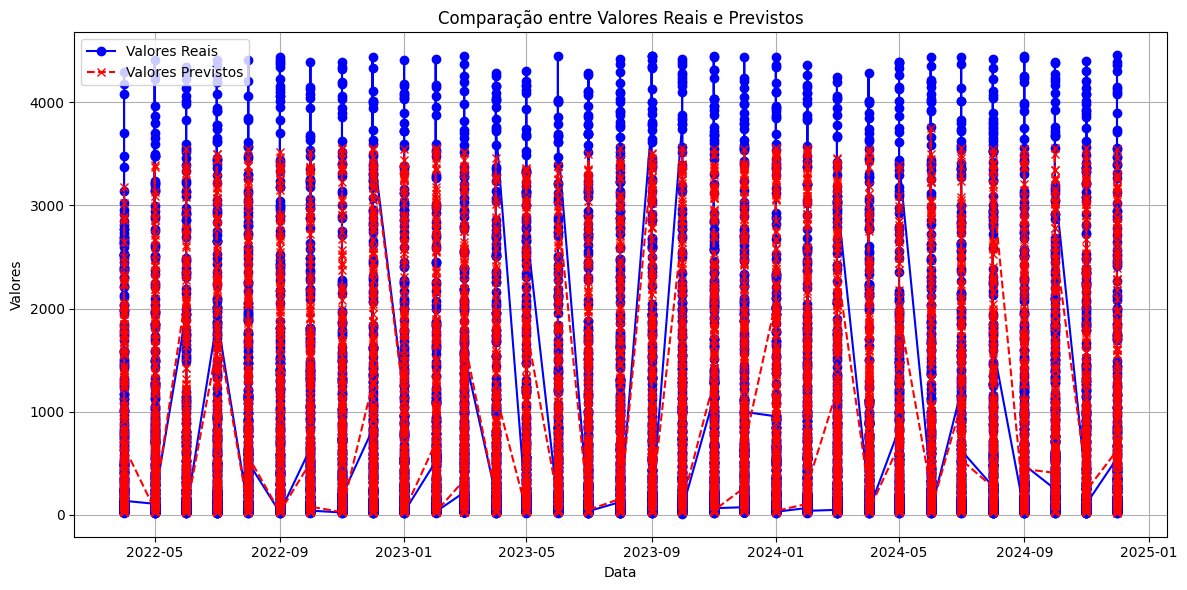

In [25]:
y_pred = pd.DataFrame(y_pred)
# DataFrame para facilitar a manipulação
df = pd.DataFrame({
    'Date': X_test['data'],
    'Actual': y_test['VALOR_FATURA'],
    'Predicted': y_pred[0]
})

# Ordenar por data 
df = df.sort_values('Date')

# Plotar os valores reais e previstos
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Actual'], label='Valores Reais', color='blue', linestyle='-', marker='o')
plt.plot(df['Date'], df['Predicted'], label='Valores Previstos', color='red', linestyle='--', marker='x')

# Configurações do gráfico
plt.title('Comparação entre Valores Reais e Previstos')
plt.xlabel('Data')
plt.ylabel('Valores')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Mostrar o gráfico
plt.show()

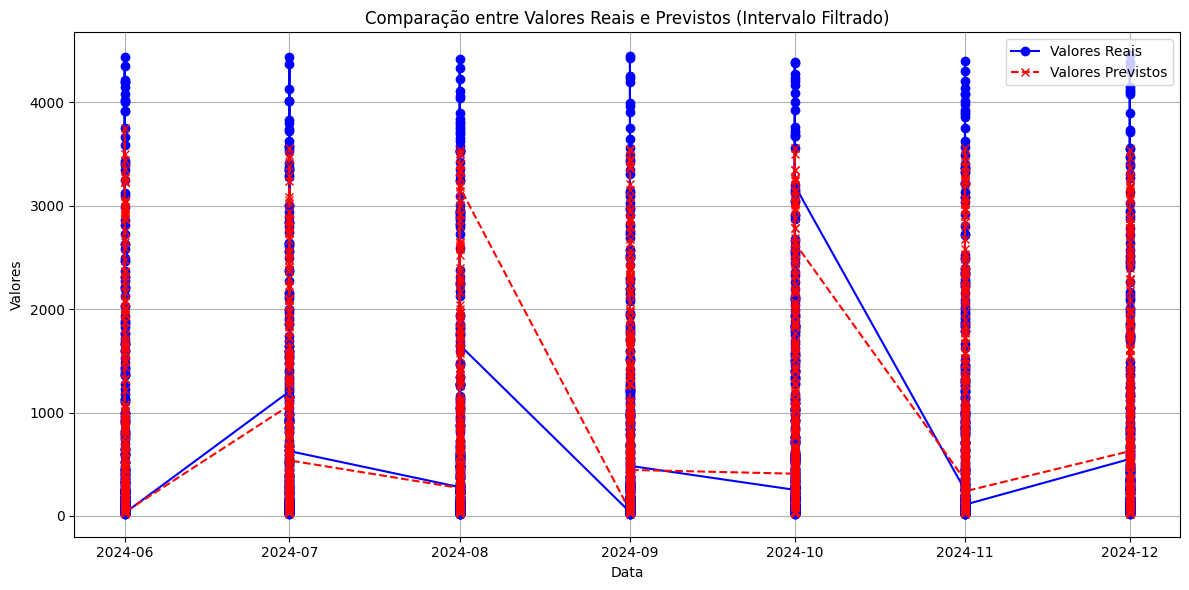

In [26]:
# Filtrar por valores de datas aleatórios (substitua essas datas pelos valores desejados)
start_date = '2024-06-01'  # Substitua por sua data inicial
end_date = '2024-12-01'    # Substitua por sua data final

# Filtrar o DataFrame
df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Plotar os valores reais e previstos para o intervalo filtrado
plt.figure(figsize=(12, 6))
plt.plot(df_filtered['Date'], df_filtered['Actual'], label='Valores Reais', color='blue', linestyle='-', marker='o')
plt.plot(df_filtered['Date'], df_filtered['Predicted'], label='Valores Previstos', color='red', linestyle='--', marker='x')

# Configurações do gráfico
plt.title('Comparação entre Valores Reais e Previstos (Intervalo Filtrado)')
plt.xlabel('Data')
plt.ylabel('Valores')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Mostrar o gráfico
plt.show()

## Testando modelo com uma matricula aleatória

In [27]:
from modulos.model_pre_processing import preprocessar_dados, remover_colunas
from sklearn.model_selection import train_test_split

df_test = pd.read_csv("../../data/processed/final_data.csv")
df_test.head()

,MATRICULA,DATA_VENCIMENTO,BAIRRO,VALOR_FATURA,ANO_VENCIMENTO,MES_VENCIMENTO,TRIMESTRE,VALOR_FATURA_lag1,VALOR_FATURA_lag2
0,706671,2022-04-18,BONFIM,85.06,2022,4,2,68.57,293.00
1,116852313,2022-04-18,URUCUIA,405.08,2022,4,2,2211.15,806.98
2,1068717,2022-04-18,SAO PAULO,1048.61,2022,4,2,1028.53,1029.33
3,17308976,2022-04-18,TAQUARIL,626.62,2022,4,2,470.79,421.10
4,116827173,2022-04-18,SION,35.52,2022,4,2,35.52,35.52


In [28]:
matriculas = pd.DataFrame( df_test['MATRICULA'].value_counts()) 
matriculas.head(30)


,count
MATRICULA,
706671,33
130981672,33
156976021,33
11046015,33
130982911,33
130983187,33
131083732,33
128653469,33
156976366,33


In [29]:
df_test = df_test[df_test['MATRICULA'] == 706671].reset_index(drop=True)
df_test = remover_colunas(df_test)
X = df_test.drop(columns='VALOR_FATURA')
y = df_test['VALOR_FATURA']

In [30]:
y_pred_test = xg_model.predict(X)

In [31]:
# Calculando as métricas de avaliação
mae = mean_absolute_error(y, y_pred_test)
mse = mean_squared_error(y, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_test)
explained_variance = explained_variance_score(y, y_pred_test)

# Exibindo as métricas
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Coefficient of Determination (R²): {r2}")
print(f"Explained Variance Score: {explained_variance}")

Mean Absolute Error (MAE): 84.97360212846235
Mean Squared Error (MSE): 12102.168238524593
Root Mean Squared Error (RMSE): 110.00985518818118
Coefficient of Determination (R²): -1.060660028301807
Explained Variance Score: -0.5433668915141925


C:\Users\maype\AppData\Local\Temp\ipykernel_1584\4252797227.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['data'] = pd.to_datetime(X['data'])


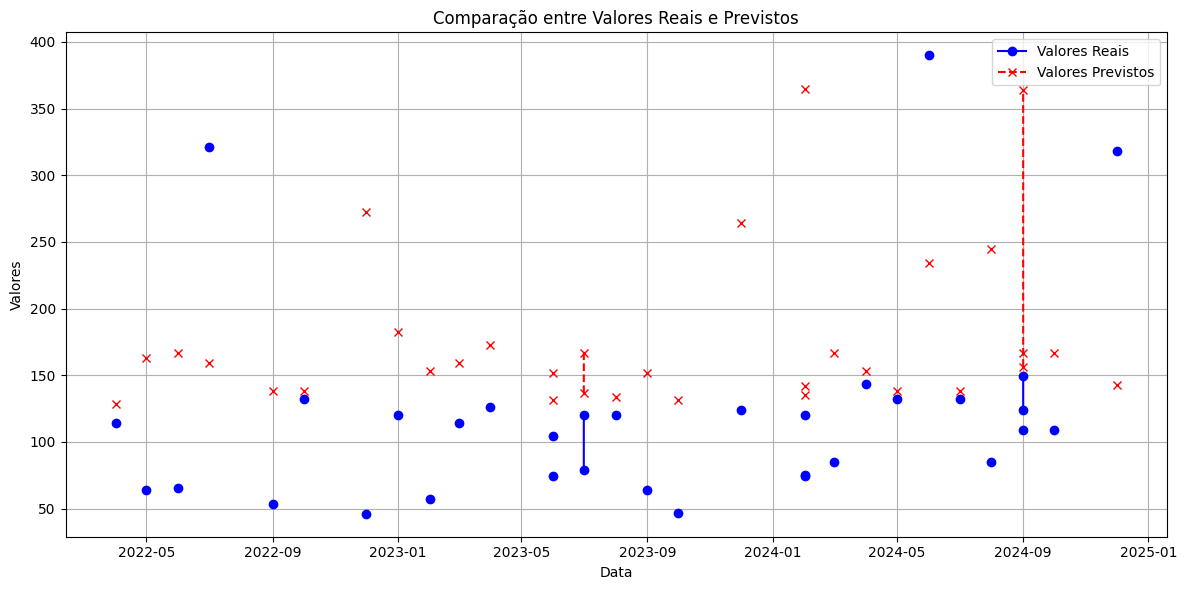

In [32]:
# Criar coluna de datas legíveis
X['data'] = (
        X['MES_VENCIMENTO'].astype(str) + '/' + X['ANO_VENCIMENTO'].astype(str)
    )

X['data'] = pd.to_datetime(X['data'])

y_pred_test = pd.DataFrame(y_pred_test)
# DataFrame para facilitar a manipulação
df = pd.DataFrame({
    'Date': X_test['data'],
    'Actual': y,
    'Predicted': y_pred_test[0]
})

# Ordenar por data 
df = df.sort_values('Date')

# Plotar os valores reais e previstos
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Actual'], label='Valores Reais', color='blue', linestyle='-', marker='o')
plt.plot(df['Date'], df['Predicted'], label='Valores Previstos', color='red', linestyle='--', marker='x')

# Configurações do gráfico
plt.title('Comparação entre Valores Reais e Previstos')
plt.xlabel('Data')
plt.ylabel('Valores')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Mostrar o gráfico
plt.show()

In [33]:
df.dropna(inplace=True)
df.head()

,Date,Actual,Predicted
3,2022-04-01,113.88,128.215118
22,2022-05-01,63.96,163.198288
27,2022-06-01,65.26,166.409805
8,2022-07-01,321.20,159.601669
15,2022-09-01,53.69,138.358398
